In [1]:
!pip install yfinance pandas numpy scipy matplotlib --quiet

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
TICKERS          = ['AAPL', 'MSFT', 'GOOGL']
WEIGHTS          = [0.5, 0.3, 0.2]
START_DATE       = '2020-01-01'
END_DATE         = '2024-12-31'
CONFIDENCE_LEVEL = 0.95
PORTFOLIO_VALUE  = 100_000
MC_SIMULATIONS   = 10_000

In [4]:
raw    = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
prices = raw.dropna()
print(f'Downloaded {len(prices)} trading days for {list(prices.columns)}')

[*********************100%***********************]  3 of 3 completed

Downloaded 1257 trading days for ['AAPL', 'GOOGL', 'MSFT']


In [5]:
log_returns = np.log(prices / prices.shift(1)).dropna()

n = log_returns.shape[1]
w = np.array(WEIGHTS) if WEIGHTS else np.ones(n) / n

port_returns = log_returns @ w
print(f'Observations : {len(port_returns)}')
print(f'Mean daily   : {port_returns.mean():.4%}')
print(f'Daily vol    : {port_returns.std():.4%}')

Observations : 1256
Mean daily   : 0.0903%
Daily vol    : 1.8031%


In [6]:
alpha = 1 - CONFIDENCE_LEVEL

# --- Historical ---
hist_var_pct  = np.percentile(port_returns, alpha * 100)
hist_cvar_pct = port_returns[port_returns <= hist_var_pct].mean()
hist_var_usd  = abs(hist_var_pct)  * PORTFOLIO_VALUE
hist_cvar_usd = abs(hist_cvar_pct) * PORTFOLIO_VALUE

# --- Parametric (Gaussian) ---
mu    = port_returns.mean()
sigma = port_returns.std()
z     = stats.norm.ppf(alpha)
para_var_pct  = mu + z * sigma
para_cvar_pct = mu - sigma * stats.norm.pdf(z) / alpha
para_var_usd  = abs(para_var_pct)  * PORTFOLIO_VALUE
para_cvar_usd = abs(para_cvar_pct) * PORTFOLIO_VALUE

# --- Monte Carlo ---
np.random.seed(42)
simulated     = np.random.normal(mu, sigma, MC_SIMULATIONS)
mc_var_pct    = np.percentile(simulated, alpha * 100)
mc_cvar_pct   = simulated[simulated <= mc_var_pct].mean()
mc_var_usd    = abs(mc_var_pct)  * PORTFOLIO_VALUE
mc_cvar_usd   = abs(mc_cvar_pct) * PORTFOLIO_VALUE

In [7]:
summary = pd.DataFrame({
    'Method'        : ['Historical', 'Parametric', 'Monte Carlo'],
    'VaR (%)'       : [f'{hist_var_pct:.3%}',  f'{para_var_pct:.3%}',  f'{mc_var_pct:.3%}'],
    'VaR ($)'       : [f'${hist_var_usd:,.0f}',  f'${para_var_usd:,.0f}',  f'${mc_var_usd:,.0f}'],
    'CVaR ($)'      : [f'${hist_cvar_usd:,.0f}', f'${para_cvar_usd:,.0f}', f'${mc_cvar_usd:,.0f}'],
}).set_index('Method')

print(f'Portfolio: {TICKERS}  |  {START_DATE} to {END_DATE}')
print(f'Confidence: {CONFIDENCE_LEVEL:.0%}  |  Value: ${PORTFOLIO_VALUE:,.0f}\n')
summary

Portfolio: ['AAPL', 'MSFT', 'GOOGL']  |  2020-01-01 to 2024-12-31
Confidence: 95%  |  Value: $100,000



,VaR (%),VaR ($),CVaR ($)
Method,,,
Historical,-2.815%,"$2,815","$4,188"
Parametric,-2.876%,"$2,876","$3,629"
Monte Carlo,-2.894%,"$2,894","$3,652"


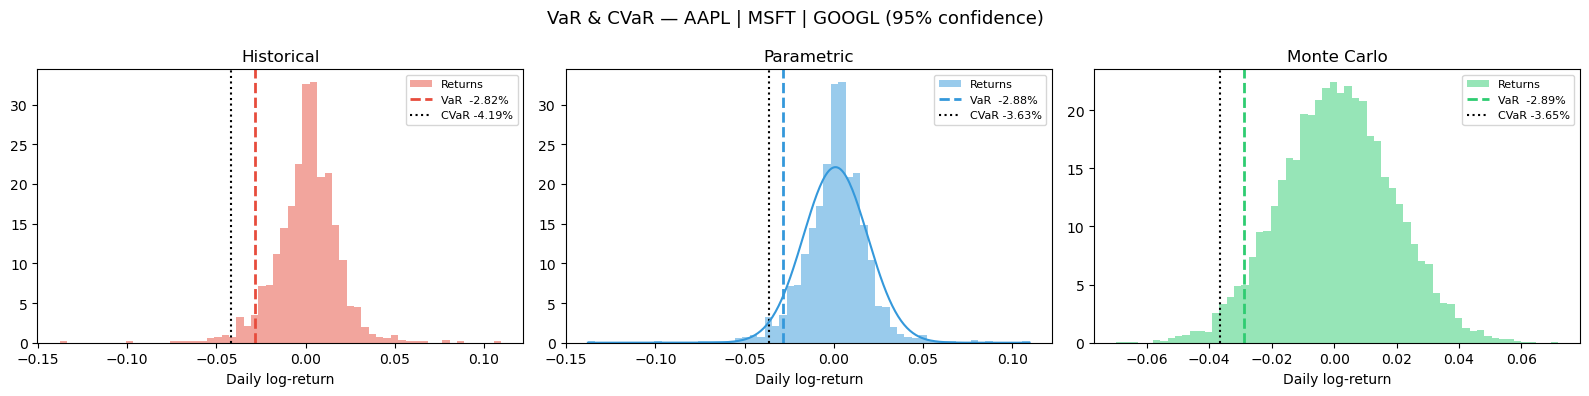

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
fig.suptitle(f'VaR & CVaR — {" | ".join(TICKERS)} ({CONFIDENCE_LEVEL:.0%} confidence)', fontsize=13)

configs = [
    ('Historical',  port_returns,  hist_var_pct,  hist_cvar_pct,  '#e74c3c'),
    ('Parametric',  port_returns,  para_var_pct,  para_cvar_pct,  '#3498db'),
    ('Monte Carlo', simulated,     mc_var_pct,    mc_cvar_pct,    '#2ecc71'),
]

for ax, (title, data, var, cvar, color) in zip(axes, configs):
    ax.hist(data, bins=60, density=True, color=color, alpha=0.5, label='Returns')
    ax.axvline(var,  color=color,   lw=2,   linestyle='--', label=f'VaR  {var:.2%}')
    ax.axvline(cvar, color='black', lw=1.5, linestyle=':',  label=f'CVaR {cvar:.2%}')
    if title == 'Parametric':
        x = np.linspace(data.min(), data.max(), 300)
        ax.plot(x, stats.norm.pdf(x, mu, sigma), color=color, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel('Daily log-return')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()